In [19]:
import requests
import pandas as pd

In [7]:
url = 'https://en.wikipedia.org/wiki/Human_body_weight'



In [8]:
import urllib3

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
response = requests.get(url, headers={'User-Agent':'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/149.0.0.0 Safari/537.36'}, verify=False)

In [9]:
response # if it is 200 then that means the request has been suceeded 

<Response [200]>

In [10]:
response.text

'<!DOCTYPE html>\n<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available skin-thumbsize-clientpref-standard" lang="en" dir="ltr">\n<head>\n<meta charset="UTF-8">\n<title>Human body weight - Wikipedia</title>\n<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disab

In [11]:
from bs4 import BeautifulSoup

In [13]:
out = BeautifulSoup(response.text, "html.parser")

In [14]:
out

<!DOCTYPE html>

<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available skin-thumbsize-clientpref-standard" dir="ltr" lang="en">
<head>
<meta charset="utf-8"/>
<title>Human body weight - Wikipedia</title>
<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled 

In [17]:
l = out.find_all('table',{'class':'wikitable'})

In [20]:
str(l[0])

'<table class="wikitable sortable">\n<tbody><tr>\n<th>Region\n</th>\n<th>Adult <br/> population<br/>(millions)\n</th>\n<th>Average weight\n</th>\n<th>% <br/> Overweight\n</th>\n<th><style data-mw-deduplicate="TemplateStyles:r1038841319">.mw-parser-output .tooltip-dotted{border-bottom:1px dotted;cursor:help}</style><span class="rt-commentedText tooltip tooltip-dotted" title="Reference">Ref</span>\n</th></tr>\n<tr>\n<td><a href="/wiki/Africa" title="Africa">Africa</a></td>\n<td>535</td>\n<td>60.7\xa0kg (133.8\xa0lb)</td>\n<td>28.9%</td>\n<td><sup class="reference" id="cite_ref-biomed_11-0"><a href="#cite_note-biomed-11"><span class="cite-bracket">[</span>11<span class="cite-bracket">]</span></a></sup>\n</td></tr>\n<tr>\n<td><a href="/wiki/Asia" title="Asia">Asia</a></td>\n<td>2,815</td>\n<td>57.7\xa0kg (127.2\xa0lb)</td>\n<td>24.2%</td>\n<td><sup class="reference" id="cite_ref-biomed_11-1"><a href="#cite_note-biomed-11"><span class="cite-bracket">[</span>11<span class="cite-bracket">]</s

In [21]:
a = pd.read_html(str(l[0]))

[                            Region  Adult population (millions)  \
 0                           Africa                          535   
 1                             Asia                         2815   
 2                           Europe                          606   
 3  Latin America and the Caribbean                          386   
 4                    North America                          263   
 5                          Oceania                           24   
 6                            World                         4630   
 
        Average weight % Overweight  \
 0  60.7 kg (133.8 lb)        28.9%   
 1  57.7 kg (127.2 lb)        24.2%   
 2  70.8 kg (156.1 lb)        55.6%   
 3  67.9 kg (149.7 lb)        57.9%   
 4  80.7 kg (177.9 lb)        73.9%   
 5  74.1 kg (163.4 lb)        63.3%   
 6  62.0 kg (136.7 lb)        34.7%   
 
   .mw-parser-output .tooltip-dotted{border-bottom:1px dotted;cursor:help}Ref  
 0                                               [11]       

In [25]:
a = pd.read_html(str(l[0]))
df = a[0]

In [26]:
df.head()

,Region,Adult population (millions),Average weight,% Overweight,.mw-parser-output .tooltip-dotted{border-bottom:1px dotted;cursor:help}Ref
0,Africa,535,60.7 kg (133.8 lb),28.9%,[11]
1,Asia,2815,57.7 kg (127.2 lb),24.2%,[11]
2,Europe,606,70.8 kg (156.1 lb),55.6%,[11]
3,Latin America and the Caribbean,386,67.9 kg (149.7 lb),57.9%,[11]
4,North America,263,80.7 kg (177.9 lb),73.9%,[11]


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 5 columns):
 #   Column                                                                      Non-Null Count  Dtype 
---  ------                                                                      --------------  ----- 
 0   Region                                                                      7 non-null      object
 1   Adult population (millions)                                                 7 non-null      int64 
 2   Average weight                                                              7 non-null      object
 3   % Overweight                                                                7 non-null      object
 4   .mw-parser-output .tooltip-dotted{border-bottom:1px dotted;cursor:help}Ref  7 non-null      object
dtypes: int64(1), object(4)
memory usage: 412.0+ bytes


In [31]:
df.drop(columns='.mw-parser-output .tooltip-dotted{border-bottom:1px dotted;cursor:help}Ref', inplace=True)

In [32]:
df.head()

,Region,Adult population (millions),Average weight,% Overweight
0,Africa,535,60.7 kg (133.8 lb),28.9%
1,Asia,2815,57.7 kg (127.2 lb),24.2%
2,Europe,606,70.8 kg (156.1 lb),55.6%
3,Latin America and the Caribbean,386,67.9 kg (149.7 lb),57.9%
4,North America,263,80.7 kg (177.9 lb),73.9%


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Region                       7 non-null      object
 1   Adult population (millions)  7 non-null      int64 
 2   Average weight               7 non-null      object
 3   % Overweight                 7 non-null      object
dtypes: int64(1), object(3)
memory usage: 356.0+ bytes


In [34]:
df['Average weight']

0    60.7 kg (133.8 lb)
1    57.7 kg (127.2 lb)
2    70.8 kg (156.1 lb)
3    67.9 kg (149.7 lb)
4    80.7 kg (177.9 lb)
5    74.1 kg (163.4 lb)
6    62.0 kg (136.7 lb)
Name: Average weight, dtype: object

In [35]:
a = '60.7 kg (133.8 lb)'

In [36]:
a.split("(")

['60.7 kg ', '133.8 lb)']

In [37]:
a.split("(")[0]

'60.7 kg '

In [38]:
import re

In [41]:
float(re.findall("\d+\.\d+", a.split("(")[0])[0])

60.7

In [47]:
df['Average weight (kgs)']=df['Average weight'].apply(lambda x: float(re.findall("\d+\.\d+", x.split("(")[0])[0]))

In [48]:
df.head()

,Region,Adult population (millions),Average weight,% Overweight,Average weight (kgs)
0,Africa,535,60.7 kg (133.8 lb),28.9%,60.7
1,Asia,2815,57.7 kg (127.2 lb),24.2%,57.7
2,Europe,606,70.8 kg (156.1 lb),55.6%,70.8
3,Latin America and the Caribbean,386,67.9 kg (149.7 lb),57.9%,67.9
4,North America,263,80.7 kg (177.9 lb),73.9%,80.7


In [45]:
a = '60.7 kg (133.8 lb)'

In [46]:
a.split("(")[1]

'133.8 lb)'

In [49]:
float(re.findall("\d+\.\d+", a.split("(")[1])[0])

133.8

In [50]:
df['Average weight (lbs)']=df['Average weight'].apply(lambda x: float(re.findall("\d+\.\d+", x.split("(")[1])[0]))

In [51]:
df.head()

,Region,Adult population (millions),Average weight,% Overweight,Average weight (kgs),Average weight (lbs)
0,Africa,535,60.7 kg (133.8 lb),28.9%,60.7,133.8
1,Asia,2815,57.7 kg (127.2 lb),24.2%,57.7,127.2
2,Europe,606,70.8 kg (156.1 lb),55.6%,70.8,156.1
3,Latin America and the Caribbean,386,67.9 kg (149.7 lb),57.9%,67.9,149.7
4,North America,263,80.7 kg (177.9 lb),73.9%,80.7,177.9


In [52]:
df.drop(columns='Average weight', inplace = True)

In [53]:
df.head()

,Region,Adult population (millions),% Overweight,Average weight (kgs),Average weight (lbs)
0,Africa,535,28.9%,60.7,133.8
1,Asia,2815,24.2%,57.7,127.2
2,Europe,606,55.6%,70.8,156.1
3,Latin America and the Caribbean,386,57.9%,67.9,149.7
4,North America,263,73.9%,80.7,177.9


In [54]:
df.columns

Index(['Region', 'Adult population (millions)', '% Overweight',
       'Average weight (kgs)', 'Average weight (lbs)'],
      dtype='object')

In [57]:
df.rename(columns={'% Overweight':'Overweight(%)'}, inplace=True)

In [58]:
df.head()

,Region,Adult population (millions),Overweight(%),Average weight (kgs),Average weight (lbs)
0,Africa,535,28.9%,60.7,133.8
1,Asia,2815,24.2%,57.7,127.2
2,Europe,606,55.6%,70.8,156.1
3,Latin America and the Caribbean,386,57.9%,67.9,149.7
4,North America,263,73.9%,80.7,177.9


In [59]:
df['Overweight(%)']

0    28.9%
1    24.2%
2    55.6%
3    57.9%
4    73.9%
5    63.3%
6    34.7%
Name: Overweight(%), dtype: object

In [60]:
a = '28.9%'

In [63]:
float(re.findall("\d+\.\d+",a)[0])

28.9

In [65]:
df['Overweight']=df['Overweight(%)'].apply(lambda x : float(re.findall("\d+\.\d+",x)[0]))

In [66]:
df.head()

,Region,Adult population (millions),Overweight(%),Average weight (kgs),Average weight (lbs),Overweight
0,Africa,535,28.9%,60.7,133.8,28.9
1,Asia,2815,24.2%,57.7,127.2,24.2
2,Europe,606,55.6%,70.8,156.1,55.6
3,Latin America and the Caribbean,386,57.9%,67.9,149.7,57.9
4,North America,263,73.9%,80.7,177.9,73.9


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Africa'),
  Text(1, 0, 'Asia'),
  Text(2, 0, 'Europe'),
  Text(3, 0, 'Latin America and the Caribbean'),
  Text(4, 0, 'North America'),
  Text(5, 0, 'Oceania'),
  Text(6, 0, 'World')])

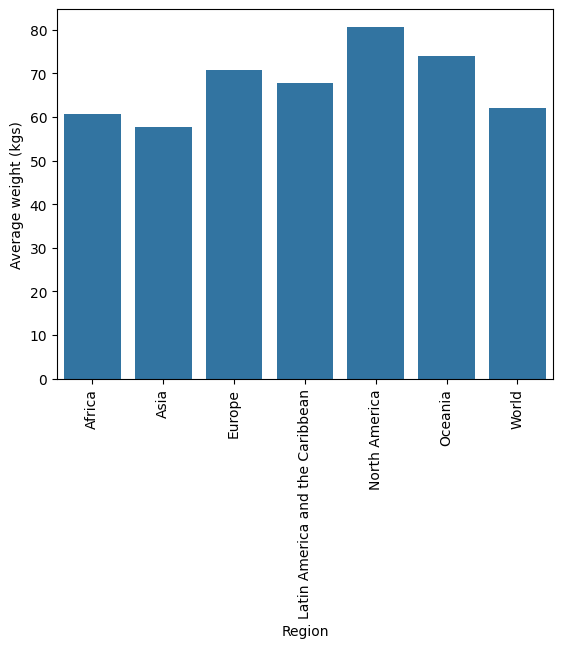

In [71]:
import seaborn as sns

sns.barplot(x=df['Region'], y=df['Average weight (kgs)'])
import matplotlib.pyplot as plt
plt.xticks(rotation=90)